# Aircraft model classifier

Fine-grained image classification: identify the manufacturer and model family of an aircraft from a photo, using transfer learning on a pretrained CNN.

This builds directly on the dogs-vs-cats transfer learning pattern, but the task is much harder: many aircraft variants are nearly visually identical (e.g. a Boeing 737-300 vs a 737-400 may differ mainly in window count). This is what makes it a genuinely interesting portfolio project, not just another image classifier.

**Pipeline:**
1. Load the FGVC-Aircraft dataset (built into torchvision, no manual download)
2. Start with the easier **manufacturer**-level task (~30 classes)
3. Fine-tune a pretrained ResNet18/34
4. Evaluate with a confusion matrix to see *which* planes get confused with which
5. Write an inference function: photo in, prediction out
6. (Stretch goal) Repeat at the harder **variant** level (100 classes) once the pipeline works


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms, models
from torchvision.datasets import FGVCAircraft
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cpu":
    print("No GPU detected — go to Runtime > Change runtime type > T4 GPU in Colab")


Using device: cuda


## 1. Load the dataset

`annotation_level` controls the granularity:
- `"manufacturer"` — ~30 classes (Boeing, Airbus, Cessna, ...) — **start here**
- `"family"` — ~70 classes (Boeing 737, Boeing 747, ...)
- `"variant"` — 100 classes (Boeing 737-300, Boeing 737-400, ...) — the hard version

First run downloads ~2.7GB once; it's cached afterward.


In [18]:
ANNOTATION_LEVEL = "manufacturer"  # change to "variant" later for the harder challenge

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = FGVCAircraft(root="./data", split="train", annotation_level=ANNOTATION_LEVEL,
                              transform=train_transform, download=True)
val_dataset = FGVCAircraft(root="./data", split="val", annotation_level=ANNOTATION_LEVEL,
                            transform=eval_transform, download=True)
test_dataset = FGVCAircraft(root="./data", split="test", annotation_level=ANNOTATION_LEVEL,
                             transform=eval_transform, download=True)

classes = train_dataset.classes
num_classes = len(classes)
print(f"Annotation level: {ANNOTATION_LEVEL}")
print(f"Classes: {num_classes}")
print(f"Train / val / test sizes: {len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}")


Annotation level: manufacturer
Classes: 30
Train / val / test sizes: 3334 / 3333 / 3333


In [19]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


## 2. Look at some sample images

Always worth eyeballing the data before training — same habit as the dogs-vs-cats notebook.


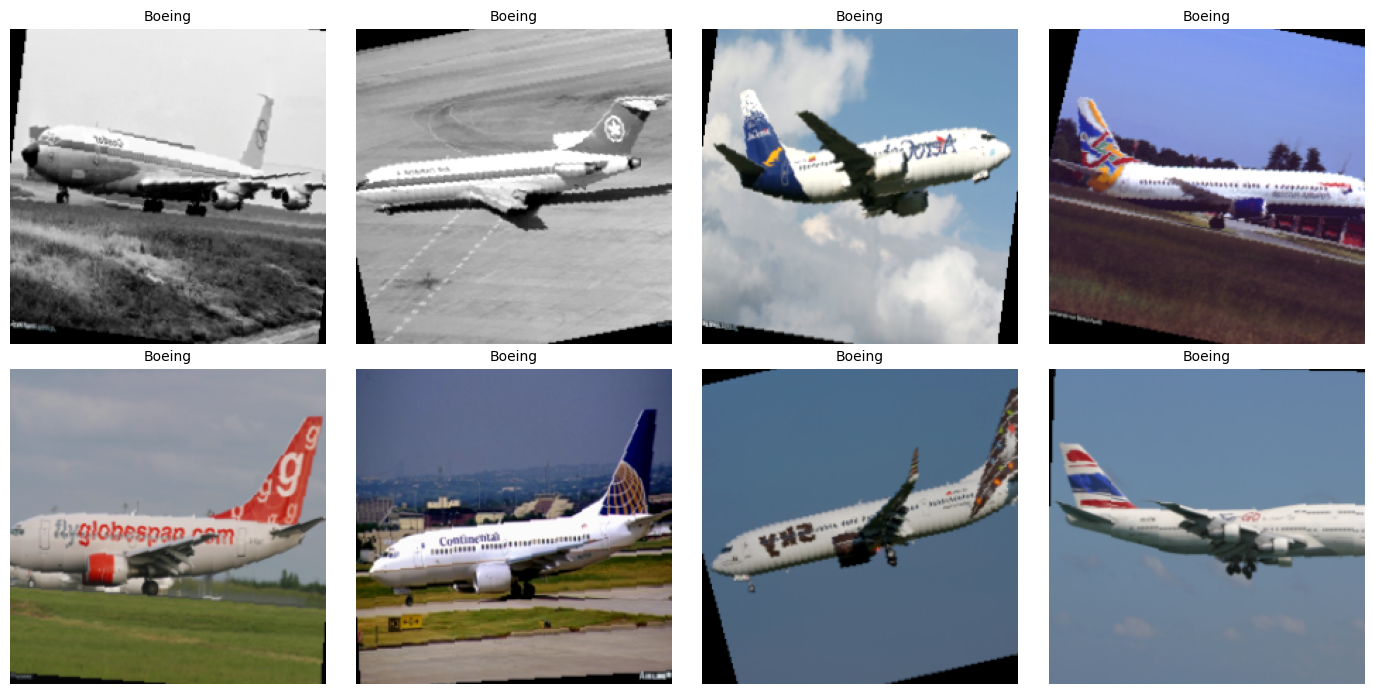

In [20]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(img_tensor * std + mean, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i * 50]
    ax.imshow(denormalize(img).permute(1, 2, 0))
    ax.set_title(classes[label], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Build the model — transfer learning

Same playbook as your VGG dogs-vs-cats assignment: take a pretrained backbone, freeze most of it,
replace the final classification layer, fine-tune.

ResNet18 is a good starting point — fast to train, strong baseline. Swap in ResNet50 later if you want
to push accuracy higher (slower, more capacity).


In [21]:
def build_model(num_classes, freeze_backbone=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the final layer — this part always trains regardless of freeze_backbone
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model.to(device)

model = build_model(num_classes, freeze_backbone=False)
print(model.fc)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 137MB/s]


Linear(in_features=2048, out_features=30, bias=True)


## 4. Training loop

Standard supervised training loop — same structure as Class 3 (loss, optimizer, epochs, batches),
plus validation at the end of each epoch to watch for overfitting (Class 4).


In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # only training the new head for now
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


In [23]:
NUM_EPOCHS = 25

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  -> new best model saved (val_acc={val_acc:.3f})")

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train loss {train_loss:.3f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.3f} acc {val_acc:.3f}")


  -> new best model saved (val_acc=0.515)
Epoch 1/25 | train loss 2.180 acc 0.368 | val loss 1.527 acc 0.515
  -> new best model saved (val_acc=0.719)
Epoch 2/25 | train loss 1.131 acc 0.653 | val loss 0.887 acc 0.719
  -> new best model saved (val_acc=0.774)
Epoch 3/25 | train loss 0.661 acc 0.805 | val loss 0.704 acc 0.774
  -> new best model saved (val_acc=0.775)
Epoch 4/25 | train loss 0.400 acc 0.891 | val loss 0.757 acc 0.775
Epoch 5/25 | train loss 0.308 acc 0.907 | val loss 0.737 acc 0.775
  -> new best model saved (val_acc=0.865)
Epoch 6/25 | train loss 0.165 acc 0.958 | val loss 0.439 acc 0.865
  -> new best model saved (val_acc=0.872)
Epoch 7/25 | train loss 0.114 acc 0.974 | val loss 0.409 acc 0.872
Epoch 8/25 | train loss 0.100 acc 0.974 | val loss 0.460 acc 0.859
Epoch 9/25 | train loss 0.068 acc 0.984 | val loss 0.443 acc 0.867
  -> new best model saved (val_acc=0.873)
Epoch 10/25 | train loss 0.073 acc 0.982 | val loss 0.424 acc 0.873
  -> new best model saved (val_acc=

## 5. Plot training curves

Watch for the classic overfitting signature from Class 4: train accuracy climbing while val accuracy
plateaus or drops. If you see that, it's a signal to unfreeze more layers slowly, add dropout, or add
more augmentation rather than just training longer.


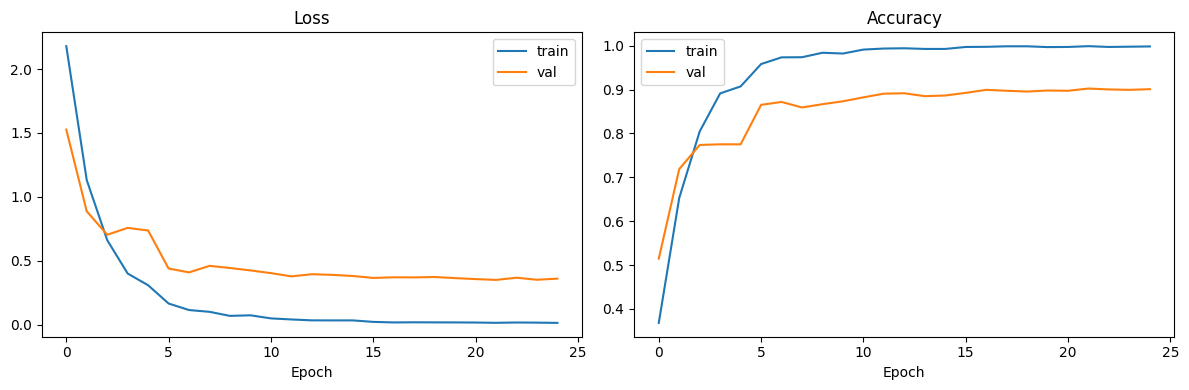

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="train")
ax1.plot(history["val_loss"], label="val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history["train_acc"], label="train")
ax2.plot(history["val_acc"], label="val")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()


## 6. Test set evaluation + confusion matrix

The confusion matrix is the genuinely interesting part of this project — it shows *which* aircraft get
mixed up with which. For manufacturer-level, mistakes should be rare and somewhat random. If you move
to variant-level later, you'll likely see tight clusters of confusion (e.g. 737 variants confused with
each other, A320 variants confused with each other) — that's the visual signature of fine-grained
classification difficulty, and it's worth a screenshot for your portfolio writeup.


Test accuracy: 0.895


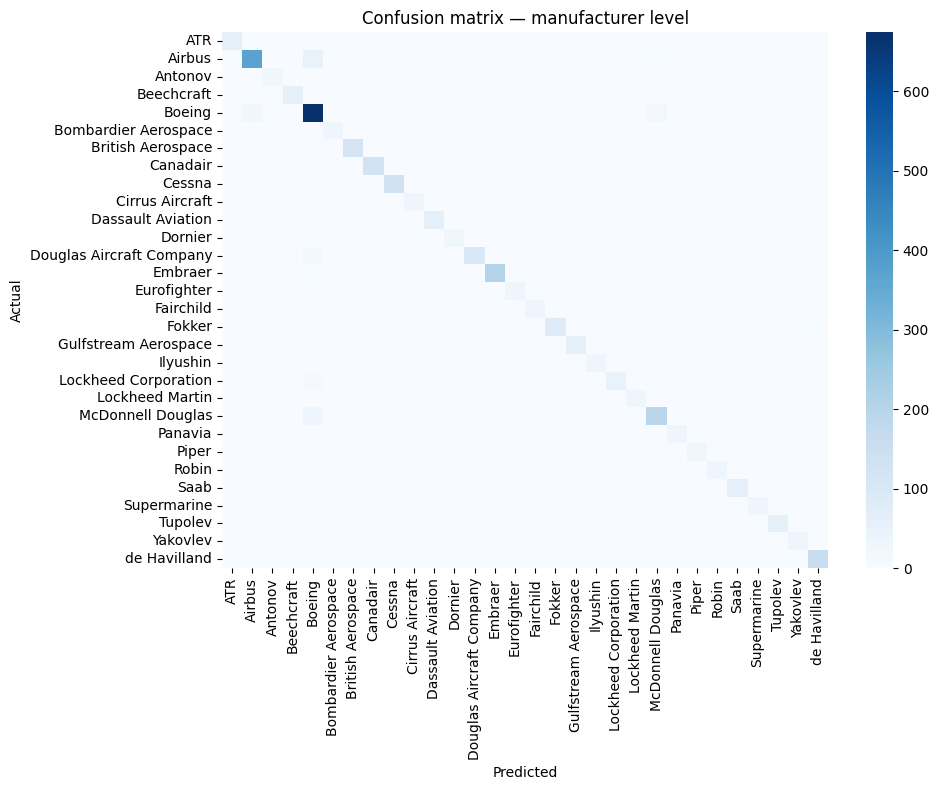

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test accuracy: {test_acc:.3f}")

preds, labels = get_predictions(model, test_loader)
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, xticklabels=classes, yticklabels=classes, cmap="Blues", annot=num_classes <= 15, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix — {ANNOTATION_LEVEL} level")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Inference function — the piece you'll reuse in the app later

This is the function that eventually powers "take a photo, get an answer." Keep its signature simple:
takes a PIL image, returns the predicted class and confidence.


In [26]:
from PIL import Image

def predict_aircraft(model, pil_image, classes, top_k=3):
    model.eval()
    img_tensor = eval_transform(pil_image.convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]

    top_probs, top_idxs = probs.topk(top_k)

    results = [(classes[idx], prob.item()) for idx, prob in zip(top_idxs.cpu(), top_probs.cpu())]
    return results

# Try it on a test image
test_img, true_label = test_dataset[0]
test_img_pil = Image.open(test_dataset._image_files[0]).convert("RGB")

predictions = predict_aircraft(model, test_img_pil, classes)
print(f"True label: {classes[true_label]}")
print("Predictions:")
for name, prob in predictions:
    print(f"  {name}: {prob:.1%}")


True label: Boeing
Predictions:
  Boeing: 99.7%
  Airbus: 0.1%
  McDonnell Douglas: 0.0%


## 8. Save the model

Save the trained weights so you can reload them later without retraining — this file is what your
future app will load.


In [27]:
torch.save({
    "model_state_dict": model.state_dict(),
    "classes": classes,
    "annotation_level": ANNOTATION_LEVEL,
}, f"aircraft_classifier_{ANNOTATION_LEVEL}.pth")

print(f"Saved aircraft_classifier_{ANNOTATION_LEVEL}.pth")

# In Colab, download it to your computer, or save to Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')


Saved aircraft_classifier_manufacturer.pth


In [30]:
from google.colab import files
uploaded = files.upload()  # this opens a button to pick a photo from your computer

img_path = list(uploaded.keys())[0]
my_image = Image.open(img_path).convert("RGB")

predictions = predict_aircraft(model, my_image, classes)
print("Predictions:")
for name, prob in predictions:
    print(f"  {name}: {prob:.1%}")

Saving Screenshot 2026-06-20 at 5.39.26 PM.png to Screenshot 2026-06-20 at 5.39.26 PM (2).png
Predictions:
  Boeing: 93.1%
  Airbus: 6.3%
  Embraer: 0.2%
